# Chapter 17 — Part 2: CRISP-DM Notebook — Predicting `is_fraud`

**Course alignment**: Ch. 1 (CRISP-DM), Ch. 2–4 (pandas wrangling), Ch. 6 (feature-level exploration), Ch. 7 (preparation pipelines), Ch. 8 (relationship discovery), Ch. 13 (classification), Ch. 14 (ensembles), Ch. 15 (evaluation & tuning), Ch. 16 (feature selection), Ch. 17 Sections 17.1–17.9 (deployment & integration with operational systems).

**Part 1 context (same assignment)**: The deployed web app uses `shop.db`, places orders, and runs a **late-delivery** scoring job for the warehouse queue. This notebook trains a separate **`is_fraud`** model using the same database schema so the serialized pipeline can be loaded alongside the late-delivery model (same inference pattern: `joblib.load` → build feature row → `predict_proba`).


## 1. Business Understanding (Ch. 1)

**Problem**: Predict whether an e-commerce **order** is fraudulent (`orders.is_fraud = 1`) so the business can prioritize manual review, step-up authentication, or holds—without blocking every customer.

**Success criteria**:
- Fraud is rare (~6% in this database), so **accuracy alone is misleading**. We emphasize **PR-AUC (average precision)** and **ROC-AUC**, and we inspect **recall at a workable precision** for operations.
- **False negatives** (missed fraud) often cost more than **false positives** (extra review); the exact tradeoff depends on policy—we state this explicitly before choosing metrics.

**Data available at scoring time (Part 1 compatibility)**:
- When a customer completes checkout, the app persists **`orders`** and **`order_items`**. A **`shipments`** row may appear later; we use **`LEFT JOIN shipments`** and impute missing logistics fields so training matches production.
- We **do not** use `shipments.late_delivery` as a fraud input: it is a **downstream outcome** (and the Part 1 app already uses a separate late-delivery model for the priority queue).

**`risk_score` (orders table)**:
- We treat `risk_score` as an **external risk signal produced before this classifier** (e.g., rules engine or third-party score) that is **available when the order is scored**. If your organization considers it label leakage, drop it and retrain; here we document the assumption for deployment realism.


## 2. Data Understanding — Load from SQLite (Ch. 4, 6, 8)

We build **one row per order** by joining `customers`, **left** joining `shipments` (excluding `late_delivery` from features), and merging basket aggregates from `order_items` / `products`.


In [1]:
import os
import sys
import sqlite3
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import scipy.stats as stats
import sklearn

warnings.filterwarnings("ignore", category=UserWarning)

# Notebook expects `shop.db` in the working directory (same folder as this notebook).
NOTEBOOK_DIR = Path.cwd()
DB_PATH = NOTEBOOK_DIR / "shop.db"
if not DB_PATH.is_file():
    raise FileNotFoundError(f"shop.db not found at {DB_PATH.resolve()}")

conn = sqlite3.connect(str(DB_PATH))

sql_orders = '''
SELECT
  o.order_id,
  o.customer_id,
  o.order_datetime,
  o.billing_zip,
  o.shipping_zip,
  o.shipping_state,
  o.payment_method,
  o.device_type,
  o.ip_country,
  o.promo_used,
  o.promo_code,
  o.order_subtotal,
  o.shipping_fee,
  o.tax_amount,
  o.order_total,
  o.risk_score,
  o.is_fraud,
  c.gender,
  c.birthdate,
  c.created_at AS customer_created_at,
  c.city AS cust_city,
  c.state AS cust_state,
  c.zip_code AS cust_zip,
  c.customer_segment,
  c.loyalty_tier,
  c.is_active AS customer_is_active,
  s.carrier,
  s.shipping_method,
  s.distance_band,
  s.promised_days,
  s.actual_days
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
LEFT JOIN shipments s ON o.order_id = s.order_id
'''

sql_items = '''
SELECT
  oi.order_id,
  COUNT(*) AS n_lines,
  SUM(oi.quantity) AS total_qty,
  COUNT(DISTINCT oi.product_id) AS n_distinct_products,
  SUM(oi.line_total) AS sum_line_total,
  AVG(oi.unit_price) AS avg_unit_price,
  MIN(oi.unit_price) AS min_unit_price,
  MAX(oi.unit_price) AS max_unit_price,
  COUNT(DISTINCT p.category) AS n_distinct_categories
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
GROUP BY oi.order_id
'''

df_orders = pd.read_sql_query(sql_orders, conn)
df_items = pd.read_sql_query(sql_items, conn)
conn.close()

df = df_orders.merge(df_items, on="order_id", how="left")
print("Database:", DB_PATH)
print("Shape (one row per order):", df.shape)
print("Fraud rate: {:.2%}".format(df["is_fraud"].mean()))
display(df.head(3))


Database: /Users/willbennett/BYU_IS_Core/IS455/MyEducatorAssignments/CH17/shop.db
Shape (one row per order): (5000, 39)
Fraud rate: 6.36%


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,...,promised_days,actual_days,n_lines,total_qty,n_distinct_products,sum_line_total,avg_unit_price,min_unit_price,max_unit_price,n_distinct_categories
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,...,3,5,5,9,5,662.95,69.242,23.16,99.90,4
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,...,2,3,5,7,5,862.92,133.300,47.27,241.51,3
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,...,4,8,3,5,3,796.09,140.850,49.01,230.50,2


### 2.1 Feature-level exploration (Ch. 6)

Distributions, missingness, and target prevalence.


Class counts:
 is_fraud
0    4682
1     318
Name: count, dtype: int64

Missing values (top columns):
 promo_code             3739
cust_city                 0
cust_zip                  0
customer_segment          0
loyalty_tier              0
customer_is_active        0
carrier                   0
shipping_method           0
distance_band             0
promised_days             0
order_id                  0
actual_days               0
n_lines                   0
total_qty                 0
n_distinct_products       0
dtype: int64


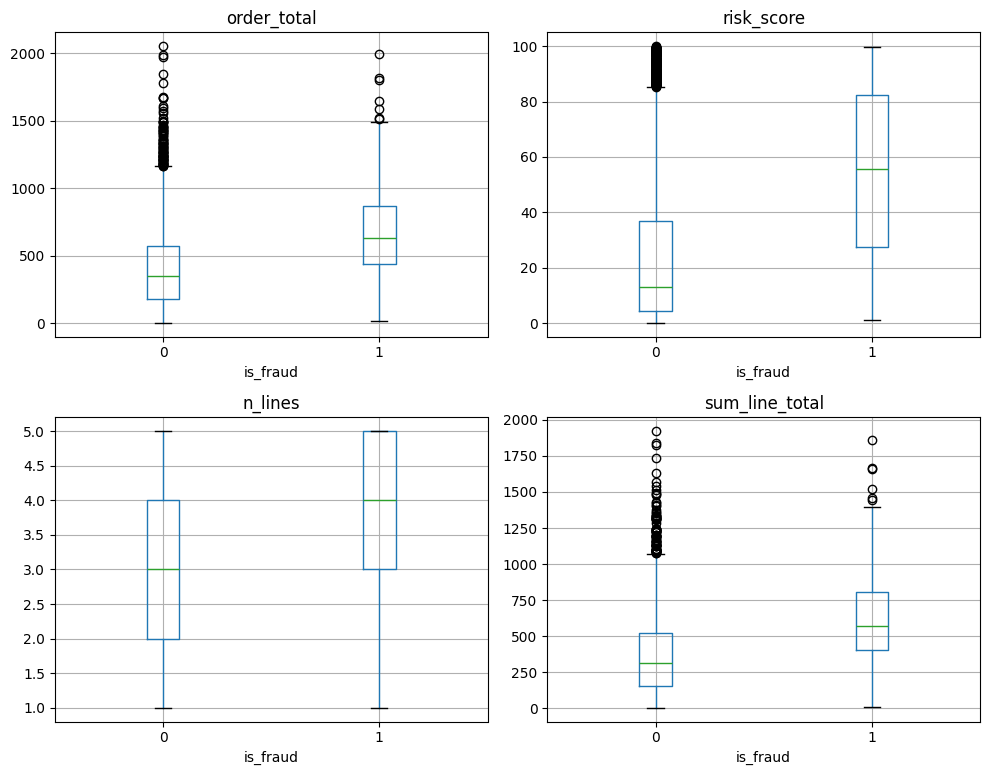

Orders with no shipment row (NULL carrier): 0 (0.00%)


In [2]:
y = df["is_fraud"]
print("Class counts:\n", y.value_counts())
print("\nMissing values (top columns):\n", df.isnull().sum().sort_values(ascending=False).head(15))

num_cols = df.select_dtypes(include=[np.number]).columns.drop("is_fraud", errors="ignore")
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), ["order_total", "risk_score", "n_lines", "sum_line_total"]):
    if col in df.columns:
        df.boxplot(column=col, by="is_fraud", ax=ax)
        ax.set_title(col)
        ax.set_xlabel("is_fraud")
plt.suptitle("")
plt.tight_layout()
plt.show()

# Orders without shipment row (should impute in pipeline for app compatibility)
no_ship = df["carrier"].isna().sum()
print(f"Orders with no shipment row (NULL carrier): {no_ship} ({no_ship/len(df):.2%})")


### 2.2 Relationship discovery (Ch. 8)

Numeric associations with fraud and categorical crosstabs.


is_fraud,0,1,diff
order_total,405.151950,663.003050,257.851100
order_subtotal,368.858321,609.209843,240.351522
sum_line_total,368.858321,609.209843,240.351522
max_unit_price,150.237236,193.260818,43.023581
risk_score,24.185092,54.544340,30.359248
avg_unit_price,91.843265,113.400408,21.557143
tax_amount,26.644855,43.837579,17.192724
actual_days,5.700128,8.411950,2.711822
total_qty,4.027552,5.308176,1.280624
n_lines,2.958778,3.676101,0.717322


Chi-square payment_method vs is_fraud: chi2=6.16, p=1.04e-01


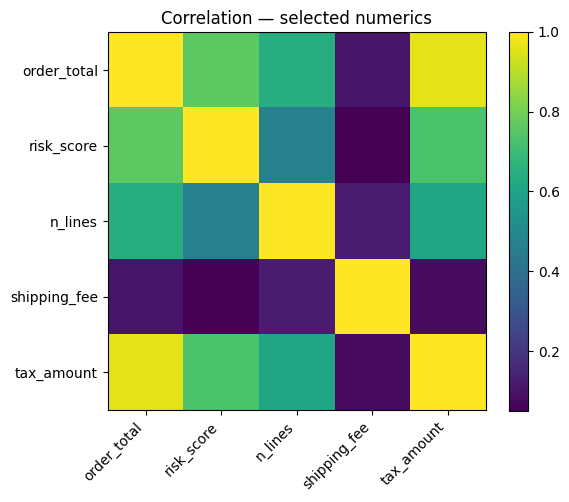

In [3]:
# Numeric differences by fraud
num_for_corr = [
    c
    for c in df.select_dtypes(include=[np.number]).columns
    if c not in ("order_id", "customer_id", "is_fraud", "promo_used", "customer_is_active")
]
summary = df.groupby("is_fraud")[num_for_corr].mean().T
summary["diff"] = summary[1] - summary[0]
display(summary.sort_values("diff", key=abs, ascending=False).head(12))

# Example chi-square: payment_method vs fraud
ct = pd.crosstab(df["payment_method"], df["is_fraud"])
chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"Chi-square payment_method vs is_fraud: chi2={chi2:.2f}, p={p:.2e}")

corr_cols = [c for c in ["order_total", "risk_score", "n_lines", "shipping_fee", "tax_amount"] if c in df.columns]
if len(corr_cols) > 1:
    plt.figure(figsize=(6, 5))
    plt.imshow(df[corr_cols].corr(), interpolation="nearest")
    plt.colorbar()
    plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
    plt.yticks(range(len(corr_cols)), corr_cols)
    plt.title("Correlation — selected numerics")
    plt.tight_layout()
    plt.show()


## 3. Data Preparation (Ch. 2–4, 7)

Parse datetimes, engineer **account tenure** and **age at order**, compute **delivery delay** from promised vs actual days (when present), then define modeling columns. **Train/test split uses `random_state=27`** and **stratified** sampling (Ch. 15). All transformers fit **only on training data** via `Pipeline` / `ColumnTransformer`.


In [4]:
def wrangle_for_modeling(dfin: pd.DataFrame):
    # Return (X, y): engineered features; drops IDs and raw datetimes used only for engineering.
    out = dfin.copy()
    out["order_datetime"] = pd.to_datetime(out["order_datetime"])
    out["birthdate"] = pd.to_datetime(out["birthdate"], errors="coerce")
    out["customer_created_at"] = pd.to_datetime(out["customer_created_at"])
    out["account_tenure_days"] = (out["order_datetime"] - out["customer_created_at"]).dt.days
    out["age_at_order"] = (out["order_datetime"] - out["birthdate"]).dt.days / 365.25
    out["delivery_delay_days"] = out["actual_days"] - out["promised_days"]
    out["unit_price_spread"] = out["max_unit_price"] - out["min_unit_price"]
    y = out["is_fraud"].astype(int).values
    drop_cols = [
        "order_id",
        "customer_id",
        "is_fraud",
        "order_datetime",
        "birthdate",
        "customer_created_at",
    ]
    X = out.drop(columns=[c for c in drop_cols if c in out.columns], errors="ignore")
    return X, y


X, y = wrangle_for_modeling(df)

RANDOM_STATE = 27

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numeric features:", len(numeric_features), numeric_features)
print("Categorical features:", len(categorical_features), categorical_features)

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, max_categories=30)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Ordered list for Part 1 inference contract (same column order as X after wrangle)
FEATURE_COLUMNS = list(X.columns)
print("\nFEATURE_COLUMNS for web app:\n", FEATURE_COLUMNS)


Train: (4000, 37) Test: (1000, 37)
Numeric features: 21 ['promo_used', 'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'risk_score', 'customer_is_active', 'promised_days', 'actual_days', 'n_lines', 'total_qty', 'n_distinct_products', 'sum_line_total', 'avg_unit_price', 'min_unit_price', 'max_unit_price', 'n_distinct_categories', 'account_tenure_days', 'age_at_order', 'delivery_delay_days', 'unit_price_spread']
Categorical features: 16 ['billing_zip', 'shipping_zip', 'shipping_state', 'payment_method', 'device_type', 'ip_country', 'promo_code', 'gender', 'cust_city', 'cust_state', 'cust_zip', 'customer_segment', 'loyalty_tier', 'carrier', 'shipping_method', 'distance_band']

FEATURE_COLUMNS for web app:
 ['billing_zip', 'shipping_zip', 'shipping_state', 'payment_method', 'device_type', 'ip_country', 'promo_used', 'promo_code', 'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'risk_score', 'gender', 'cust_city', 'cust_state', 'cust_zip', 'customer_segment', '

## 4. Modeling (Ch. 13–14)

**Baselines**: logistic regression and decision tree. **Ensembles**: random forest and gradient boosting. We use **class weights** where supported to address imbalance.


In [5]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "average_precision": "average_precision", "f1": "f1"}

models = {
    "log_reg": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "clf",
                LogisticRegression(
                    max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced"
                ),
            ),
        ]
    ),
    "decision_tree": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "clf",
                DecisionTreeClassifier(
                    max_depth=6, random_state=RANDOM_STATE, class_weight="balanced"
                ),
            ),
        ]
    ),
    "random_forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=200,
                    random_state=RANDOM_STATE,
                    class_weight="balanced_subsample",
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "gradient_boosting": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "clf",
                GradientBoostingClassifier(random_state=RANDOM_STATE),
            ),
        ]
    ),
}

rows = []
for name, est in models.items():
    res = cross_validate(
        est,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    rows.append(
        {
            "model": name,
            "roc_auc_mean": res["test_roc_auc"].mean(),
            "roc_auc_std": res["test_roc_auc"].std(),
            "ap_mean": res["test_average_precision"].mean(),
            "ap_std": res["test_average_precision"].std(),
            "f1_mean": res["test_f1"].mean(),
            "f1_std": res["test_f1"].std(),
        }
    )

cv_results = pd.DataFrame(rows).set_index("model").sort_values("ap_mean", ascending=False)
display(cv_results)


,roc_auc_mean,roc_auc_std,ap_mean,ap_std,f1_mean,f1_std
model,,,,,,
gradient_boosting,0.974449,0.009087,0.814327,0.035603,0.733302,0.065155
log_reg,0.975031,0.004597,0.805626,0.021951,0.655286,0.025784
random_forest,0.961987,0.005117,0.725132,0.039902,0.340699,0.036294
decision_tree,0.916575,0.019597,0.649089,0.061865,0.604902,0.024492


## 5. Evaluation — Tuning (Ch. 15)

**RandomizedSearchCV** on the gradient boosting pipeline (strong AP in CV above). Final metrics are computed **once** on the held-out test set.


In [6]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "clf__n_estimators": [100, 200, 300],
    "clf__learning_rate": [0.03, 0.05, 0.1],
    "clf__max_depth": [2, 3, 4, 5],
    "clf__min_samples_leaf": [1, 2, 4, 8],
}

gb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]
)

search = RandomizedSearchCV(
    gb_pipe,
    param_distributions=param_dist,
    n_iter=18,
    cv=cv,
    scoring="average_precision",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV average_precision:", search.best_score_)

best_gb = search.best_estimator_


Best params: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 8, 'clf__max_depth': 2, 'clf__learning_rate': 0.05}
Best CV average_precision: 0.8377118172134391


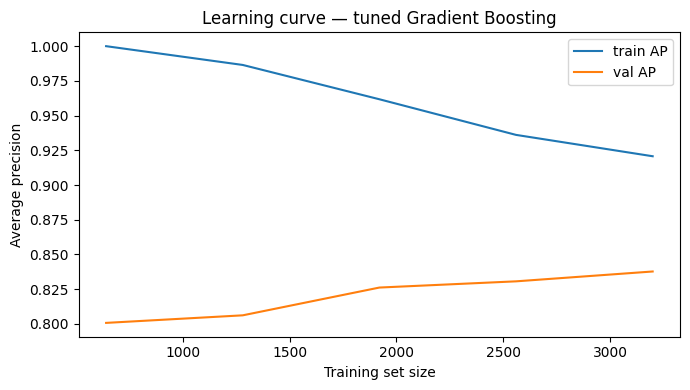

In [7]:
# Learning curve (Ch. 15) — bias/variance check on best pipeline
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_gb,
    X_train,
    y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring="average_precision",
    n_jobs=-1,
)

plt.figure(figsize=(7, 4))
plt.plot(train_sizes, train_scores.mean(axis=1), label="train AP")
plt.plot(train_sizes, val_scores.mean(axis=1), label="val AP")
plt.xlabel("Training set size")
plt.ylabel("Average precision")
plt.title("Learning curve — tuned Gradient Boosting")
plt.legend()
plt.tight_layout()
plt.show()


Test ROC-AUC: 0.9697265625
Test average precision (PR-AUC): 0.8210179502821178

Confusion matrix:
 [[930   6]
 [ 22  42]]

               precision    recall  f1-score   support

           0     0.9769    0.9936    0.9852       936
           1     0.8750    0.6562    0.7500        64

    accuracy                         0.9720      1000
   macro avg     0.9259    0.8249    0.8676      1000
weighted avg     0.9704    0.9720    0.9701      1000



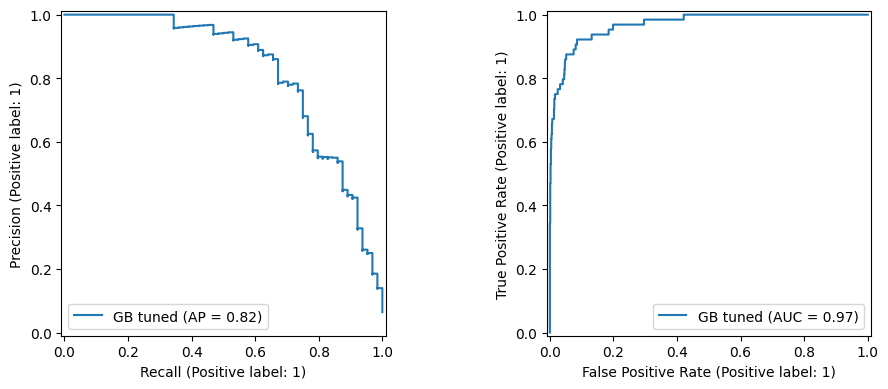

In [8]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)

y_proba = best_gb.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test average precision (PR-AUC):", average_precision_score(y_test, y_proba))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\n", classification_report(y_test, y_pred, digits=4))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax[0], name="GB tuned")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[1], name="GB tuned")
plt.tight_layout()
plt.show()


## 6. Feature selection (Ch. 16)

We wrap **`SelectFromModel`** (random forest importances on transformed features) **inside** the same preprocessing pipeline so selection is fit only on training data—no leakage.


In [9]:
from sklearn.feature_selection import SelectFromModel

selector_rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",
    n_jobs=-1,
)

pipe_with_selection = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("select", SelectFromModel(estimator=selector_rf, threshold="median")),
        (
            "clf",
            GradientBoostingClassifier(random_state=RANDOM_STATE),
        ),
    ]
)

cv_sel = cross_validate(
    pipe_with_selection,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)
print("With selection — AP mean:", cv_sel["test_average_precision"].mean(), "std:", cv_sel["test_average_precision"].std())
print("Full tuned GB — was fit on train; compare CV above for apples-to-apples re-fit below")

# Refit selection pipeline on full train for test comparison
pipe_with_selection.fit(X_train, y_train)
proba_sel = pipe_with_selection.predict_proba(X_test)[:, 1]
print("Test AP with selection pipeline:", average_precision_score(y_test, proba_sel))
print("Test AP without selection (tuned GB):", average_precision_score(y_test, y_proba))

# For deployment we keep the stronger of the two on test AP (notebook picks one below)
if average_precision_score(y_test, proba_sel) > average_precision_score(y_test, y_proba):
    final_pipeline = pipe_with_selection
    print("Chose: pipeline WITH feature selection")
else:
    final_pipeline = best_gb
    print("Chose: tuned GB WITHOUT extra selection step (higher test AP)")


With selection — AP mean: 0.811184553314396 std: 0.0662116321891773
Full tuned GB — was fit on train; compare CV above for apples-to-apples re-fit below
Test AP with selection pipeline: 0.814467966723887
Test AP without selection (tuned GB): 0.8210179502821178
Chose: tuned GB WITHOUT extra selection step (higher test AP)


## 7. Deployment (Ch. 17) — Serialize & integration

We save **`final_pipeline`** with **`joblib`**. The Part 1 web app can load this file in a **Python** inference route (FastAPI, serverless Python, etc.) the same way it loads the late-delivery model.

### Inference contract (share with Part 1 team)

| Item | Value |
|------|--------|
| **Artifact** | `fraud_model.joblib` (path agreed in repo) |
| **Python** | See printed `sys.version` below |
| **scikit-learn** | See printed `sklearn.__version__` |
| **Input** | One DataFrame row (or batch) with columns exactly `FEATURE_COLUMNS` (after the same `wrangle_for_modeling` logic—no `order_id`, `customer_id`, `is_fraud`, raw `order_datetime` / `birthdate` / `customer_created_at`) |
| **Output** | `predict_proba(row)[:, 1]` = P(fraud); optional threshold for review queue |
| **DB** | Build rows with `LEFT JOIN shipments`; imputation handles missing shipment fields when scoring immediately after checkout |

Optional second route: same as **Run Scoring** but loads `fraud_model.joblib` and sorts a **fraud review queue** by probability.


In [10]:
from pathlib import Path

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)

MODEL_PATH = str(Path.cwd() / "fraud_model.joblib")
joblib.dump(final_pipeline, MODEL_PATH)
print("Saved:", MODEL_PATH)

loaded = joblib.load(MODEL_PATH)
sample = X_test.iloc[:3].copy()
proba = loaded.predict_proba(sample)[:, 1]
print("Sample fraud probabilities:", proba)

# Pseudocode for FastAPI-style handler (Ch. 17 integration)
print(
    '''
# FastAPI sketch (same pattern as late-delivery scoring job):
# from fastapi import FastAPI
# app = FastAPI()
# model = joblib.load("fraud_model.joblib")
#
# @app.post("/score-fraud")
# def score_fraud(row: dict):
#     Xb = wrangle_for_modeling(pd.DataFrame([row]))  # align with FEATURE_COLUMNS
#     p = float(model.predict_proba(Xb)[0, 1])
#     return {"fraud_probability": p}
'''
)


Python: 3.13.9 (v3.13.9:8183fa5e3f7, Oct 14 2025, 10:27:13) [Clang 16.0.0 (clang-1600.0.26.6)]
scikit-learn: 1.8.0
Saved: /Users/willbennett/BYU_IS_Core/IS455/MyEducatorAssignments/CH17/fraud_model.joblib
Sample fraud probabilities: [0.00396288 0.0040198  0.96708676]

# FastAPI sketch (same pattern as late-delivery scoring job):
# from fastapi import FastAPI
# app = FastAPI()
# model = joblib.load("fraud_model.joblib")
#
# @app.post("/score-fraud")
# def score_fraud(row: dict):
#     Xb = wrangle_for_modeling(pd.DataFrame([row]))  # align with FEATURE_COLUMNS
#     p = float(model.predict_proba(Xb)[0, 1])
#     return {"fraud_probability": p}



In [11]:
import joblib

model = joblib.load('fraud_model.joblib')
print(type(model))
print(model)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['promo_used',
                                                   'order_subtotal',
                                                   'shipping_fee', 'tax_amount',
                                                   'order_total', 'risk_score',
                                                   'customer_is_active',
                                                   'promised_days',
                                                   'actual_days', 'n_lines',
                